In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Optional for notebook aesthetics
sns.set(style="whitegrid")
%matplotlib inline

Matplotlib is building the font cache; this may take a moment.


In [3]:
# Load your dataset (adjust file path)
df = pd.read_csv("_cancer_dataset_uae.csv")

# View top rows
df.head()

,Patient_ID,Age,Gender,Nationality,Emirate,Diagnosis_Date,Cancer_Type,Cancer_Stage,Treatment_Type,Treatment_Start_Date,Hospital,Primary_Physician,Outcome,Death_Date,Cause_of_Death,Smoking_Status,Comorbidities,Ethnicity,Weight,Height
0,PAT000001,69,Female,Emirati,Umm Al Quwain,2020-11-30,Liver,II,Radiation,2020-12-04,Sheikh Khalifa Hospital,Dr. VO41,Recovered,NaN,NaN,Non-Smoker,NaN,European,61,157
1,PAT000002,32,Male,Emirati,Umm Al Quwain,2015-10-10,Leukemia,III,Surgery,2015-11-05,Dubai Hospital,Dr. SM31,Recovered,NaN,NaN,Smoker,NaN,South Asian,80,175
2,PAT000003,89,Male,Emirati,Abu Dhabi,2018-02-13,Liver,III,Radiation,2018-08-03,Zayed Military Hospital,Dr. BC7,Under Treatment,NaN,NaN,Non-Smoker,NaN,South Asian,50,175
3,PAT000004,78,Female,Emirati,Abu Dhabi,2022-02-04,Lung,III,Radiation,2022-03-13,Cleveland Clinic Abu Dhabi,Dr. TC14,Recovered,NaN,NaN,Former Smoker,NaN,African,44,155
4,PAT000005,38,Female,Emirati,Fujairah,2019-12-03,Pancreatic,II,Chemotherapy,2020-02-29,Sheikh Khalifa Hospital,Dr. YS37,Recovered,NaN,NaN,Former Smoker,NaN,East Asian,101,160


In [5]:
# Check shape and info
df.shape
df.info()

# Check missing values
df.isnull().sum()

# Summary statistics
df.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Patient_ID            10000 non-null  object
 1   Age                   10000 non-null  int64 
 2   Gender                10000 non-null  object
 3   Nationality           10000 non-null  object
 4   Emirate               10000 non-null  object
 5   Diagnosis_Date        10000 non-null  object
 6   Cancer_Type           10000 non-null  object
 7   Cancer_Stage          10000 non-null  object
 8   Treatment_Type        10000 non-null  object
 9   Treatment_Start_Date  10000 non-null  object
 10  Hospital              10000 non-null  object
 11  Primary_Physician     10000 non-null  object
 12  Outcome               10000 non-null  object
 13  Death_Date            992 non-null    object
 14  Cause_of_Death        992 non-null    object
 15  Smoking_Status        10000 non-null 

,Patient_ID,Age,Gender,Nationality,Emirate,Diagnosis_Date,Cancer_Type,Cancer_Stage,Treatment_Type,Treatment_Start_Date,Hospital,Primary_Physician,Outcome,Death_Date,Cause_of_Death,Smoking_Status,Comorbidities,Ethnicity,Weight,Height
count,10000,10000.000000,10000,10000,10000,10000,10000,10000,10000,10000,10000,10000,10000,992,992,10000,5953,10000,10000.000000,10000.000000
unique,10000,NaN,3,2,7,3151,8,4,4,3250,4,8614,3,867,2,3,3,5,NaN,NaN
top,PAT000001,NaN,Female,Emirati,Ajman,2023-12-13,Leukemia,III,Radiation,2022-05-17,Sheikh Khalifa Hospital,Dr. AJ25,Recovered,2022-06-28 00:00:00,Complications,Non-Smoker,Hypertension,South Asian,NaN,NaN
freq,1,NaN,4985,5920,1497,12,1314,3041,2519,12,2541,5,4931,3,507,5038,2945,2083,NaN,NaN
mean,NaN,53.539700,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,69.550000,169.347500
std,NaN,20.757324,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14.933339,10.070118
min,NaN,18.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.000000,131.000000
25%,NaN,36.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,60.000000,163.000000
50%,NaN,53.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.000000,169.000000
75%,NaN,72.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,80.000000,176.000000


In [17]:
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

In [19]:
print(df.columns)

Index(['patient_id', 'age', 'gender', 'nationality', 'emirate',
       'diagnosis_date', 'cancer_type', 'cancer_stage', 'treatment_type',
       'treatment_start_date', 'hospital', 'primary_physician', 'outcome',
       'death_date', 'cause_of_death', 'smoking_status', 'comorbidities',
       'ethnicity', 'weight', 'height'],
      dtype='object')


In [21]:
print(df.columns.tolist())

['patient_id', 'age', 'gender', 'nationality', 'emirate', 'diagnosis_date', 'cancer_type', 'cancer_stage', 'treatment_type', 'treatment_start_date', 'hospital', 'primary_physician', 'outcome', 'death_date', 'cause_of_death', 'smoking_status', 'comorbidities', 'ethnicity', 'weight', 'height']


In [23]:
# Make sure diagnosis_date is in datetime format
df['diagnosis_date'] = pd.to_datetime(df['diagnosis_date'], errors='coerce')

# Create a 'year' column
df['year'] = df['diagnosis_date'].dt.year

In [25]:
# Create a binary 'recovered' column
df['recovered'] = df['outcome'].str.lower().str.strip() == 'recovered'
df['recovered'] = df['recovered'].astype(int)  # Convert True/False to 1/0

In [27]:
recovery_by_year = df.groupby('year')['recovered'].value_counts().unstack().fillna(0)
recovery_by_year['recovery_rate'] = (recovery_by_year[1] / recovery_by_year.sum(axis=1)) * 100

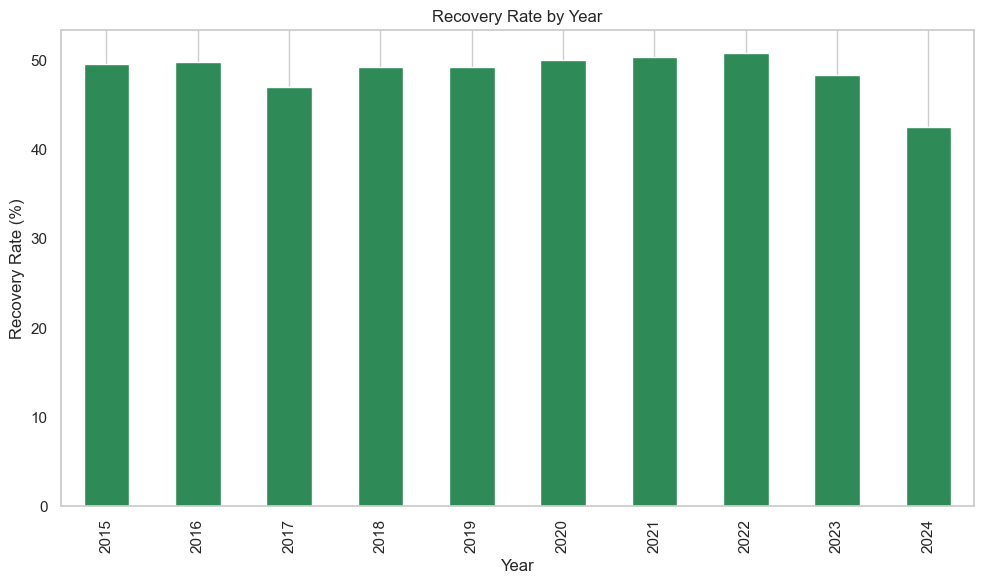

In [29]:
recovery_by_year['recovery_rate'].plot(kind='bar', figsize=(10, 6), color='seagreen')
plt.title('Recovery Rate by Year')
plt.ylabel('Recovery Rate (%)')
plt.xlabel('Year')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

In [31]:
df['recovered'] = df['outcome'].str.lower().str.strip() == 'recovered'
df['recovered'] = df['recovered'].astype(int)

In [33]:
recovery_by_year = df.groupby('year')['recovered'].value_counts().unstack().fillna(0)
recovery_by_year['recovery_rate'] = (recovery_by_year[1] / recovery_by_year.sum(axis=1)) * 100

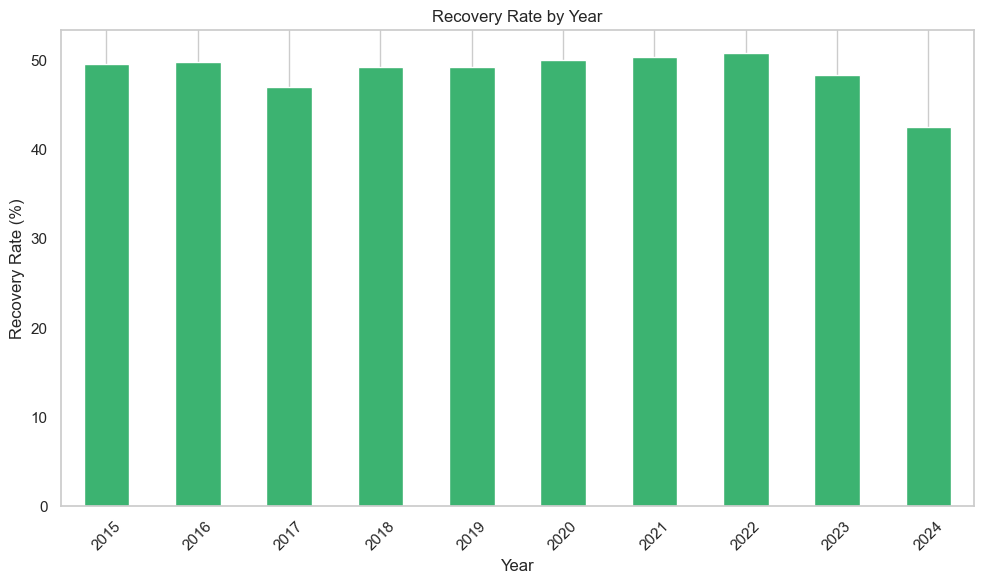

In [35]:
import matplotlib.pyplot as plt

recovery_by_year['recovery_rate'].plot(kind='bar', color='mediumseagreen', figsize=(10, 6))
plt.title('Recovery Rate by Year')
plt.ylabel('Recovery Rate (%)')
plt.xlabel('Year')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

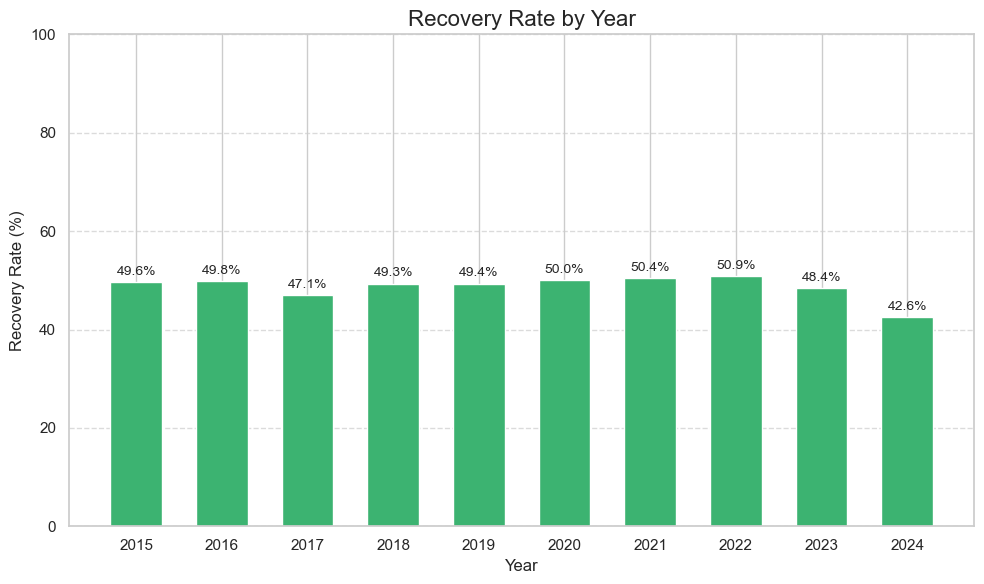

In [37]:
import matplotlib.pyplot as plt

# Sort the years to ensure bars are in order
recovery_by_year = recovery_by_year.sort_index()

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(recovery_by_year.index.astype(str), recovery_by_year['recovery_rate'], color='mediumseagreen', width=0.6)

# Add labels and formatting
ax.set_title('Recovery Rate by Year', fontsize=16)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Recovery Rate (%)', fontsize=12)
ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.set_ylim(0, 100)  # Assuming max 100% recovery rate
plt.xticks(rotation=0)  # Keep year labels straight

# Optionally, add data labels on top of bars
for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{height:.1f}%', xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points",
                ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

In [5]:
import pandas as pd

# Replace the path below with the correct one if needed
df = pd.read_csv("_cancer_dataset_uae.csv")


In [7]:
print(df.columns)

Index(['Patient_ID', 'Age', 'Gender', 'Nationality', 'Emirate',
       'Diagnosis_Date', 'Cancer_Type', 'Cancer_Stage', 'Treatment_Type',
       'Treatment_Start_Date', 'Hospital', 'Primary_Physician', 'Outcome',
       'Death_Date', 'Cause_of_Death', 'Smoking_Status', 'Comorbidities',
       'Ethnicity', 'Weight', 'Height'],
      dtype='object')


In [11]:
df['recovered'] = df['Outcome'].str.strip().str.lower() == 'recovered'

In [15]:
print(df.columns.tolist())

['Patient_ID', 'Age', 'Gender', 'Nationality', 'Emirate', 'Diagnosis_Date', 'Cancer_Type', 'Cancer_Stage', 'Treatment_Type', 'Treatment_Start_Date', 'Hospital', 'Primary_Physician', 'Outcome', 'Death_Date', 'Cause_of_Death', 'Smoking_Status', 'Comorbidities', 'Ethnicity', 'Weight', 'Height', 'recovered']


In [17]:
df['Cancer_Type']


0            Liver
1         Leukemia
2            Liver
3             Lung
4       Pancreatic
           ...    
9995       Ovarian
9996       Ovarian
9997          Lung
9998          Lung
9999         Liver
Name: Cancer_Type, Length: 10000, dtype: object

In [19]:

recovery_by_cancer = df.groupby('Cancer_Type')['recovered'].agg(['sum', 'count']).reset_index()
recovery_by_cancer['recovery_rate'] = (recovery_by_cancer['sum'] / recovery_by_cancer['count']) * 100


In [21]:
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

In [23]:
df['recovered'] = df['outcome'].str.strip().str.lower() == 'recovered'

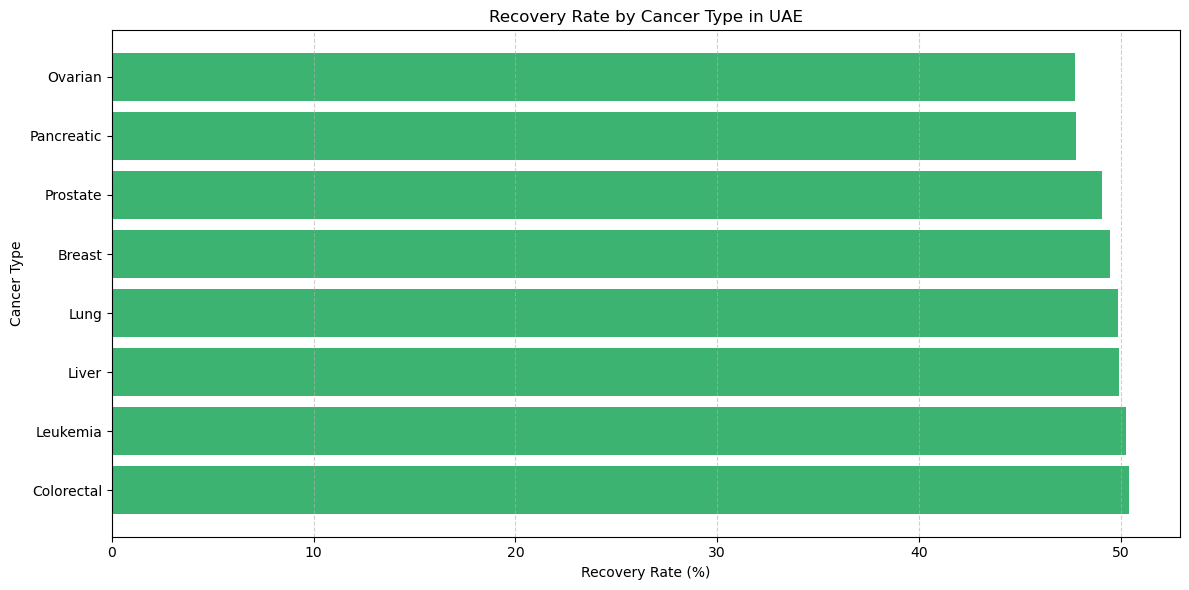

In [25]:
import matplotlib.pyplot as plt

# Group and calculate recovery rates
recovery_by_cancer = df.groupby('cancer_type')['recovered'].agg(['sum', 'count']).reset_index()
recovery_by_cancer['recovery_rate'] = (recovery_by_cancer['sum'] / recovery_by_cancer['count']) * 100

# Sort for better visuals
recovery_by_cancer = recovery_by_cancer.sort_values(by='recovery_rate', ascending=False)

# Plotting
plt.figure(figsize=(12, 6))
plt.barh(recovery_by_cancer['cancer_type'], recovery_by_cancer['recovery_rate'], color='mediumseagreen')
plt.xlabel('Recovery Rate (%)')
plt.ylabel('Cancer Type')
plt.title('Recovery Rate by Cancer Type in UAE')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

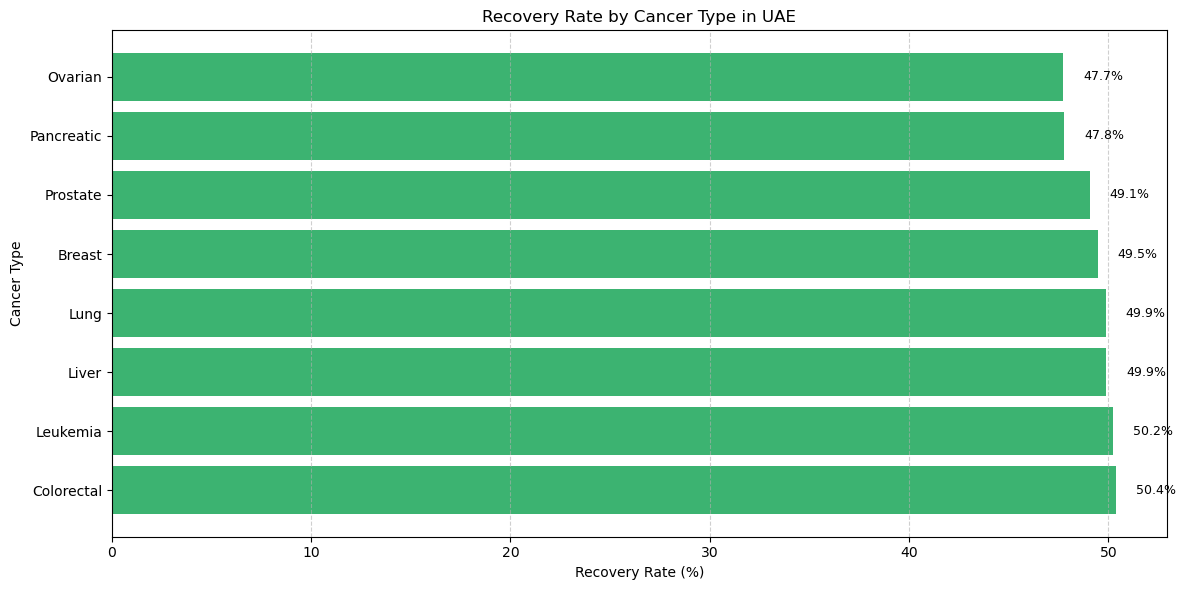

In [27]:
import matplotlib.pyplot as plt

# Group and calculate recovery rates
recovery_by_cancer = df.groupby('cancer_type')['recovered'].agg(['sum', 'count']).reset_index()
recovery_by_cancer['recovery_rate'] = (recovery_by_cancer['sum'] / recovery_by_cancer['count']) * 100

# Sort for better visuals
recovery_by_cancer = recovery_by_cancer.sort_values(by='recovery_rate', ascending=False)

# Plotting
plt.figure(figsize=(12, 6))
bars = plt.barh(recovery_by_cancer['cancer_type'], recovery_by_cancer['recovery_rate'], color='mediumseagreen')

# Add labels to each bar
for bar in bars:
    width = bar.get_width()
    plt.text(width + 1, bar.get_y() + bar.get_height() / 2,
             f'{width:.1f}%', va='center', fontsize=9)

plt.xlabel('Recovery Rate (%)')
plt.ylabel('Cancer Type')
plt.title('Recovery Rate by Cancer Type in UAE')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

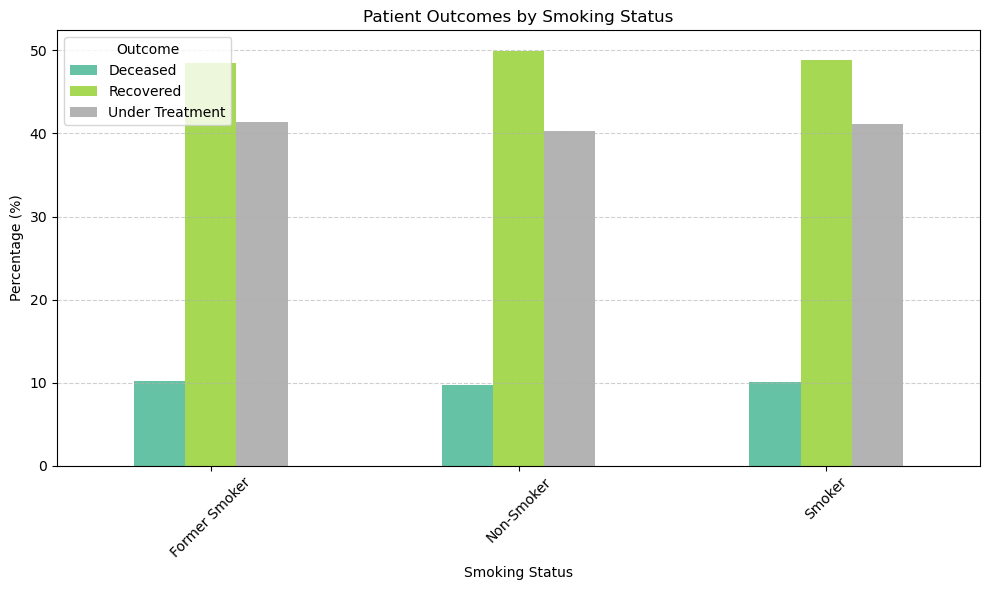

In [29]:
import pandas as pd
import matplotlib.pyplot as plt

# Group and count patients by smoking status and outcome
smoking_outcome = df.groupby(['smoking_status', 'outcome']).size().unstack().fillna(0)

# Optional: Normalize by smoking status to get percentages
smoking_outcome_percent = smoking_outcome.div(smoking_outcome.sum(axis=1), axis=0) * 100

# Plot
smoking_outcome_percent.plot(kind='bar', figsize=(10, 6), colormap='Set2')

plt.title('Patient Outcomes by Smoking Status')
plt.ylabel('Percentage (%)')
plt.xlabel('Smoking Status')
plt.xticks(rotation=45)
plt.legend(title='Outcome')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

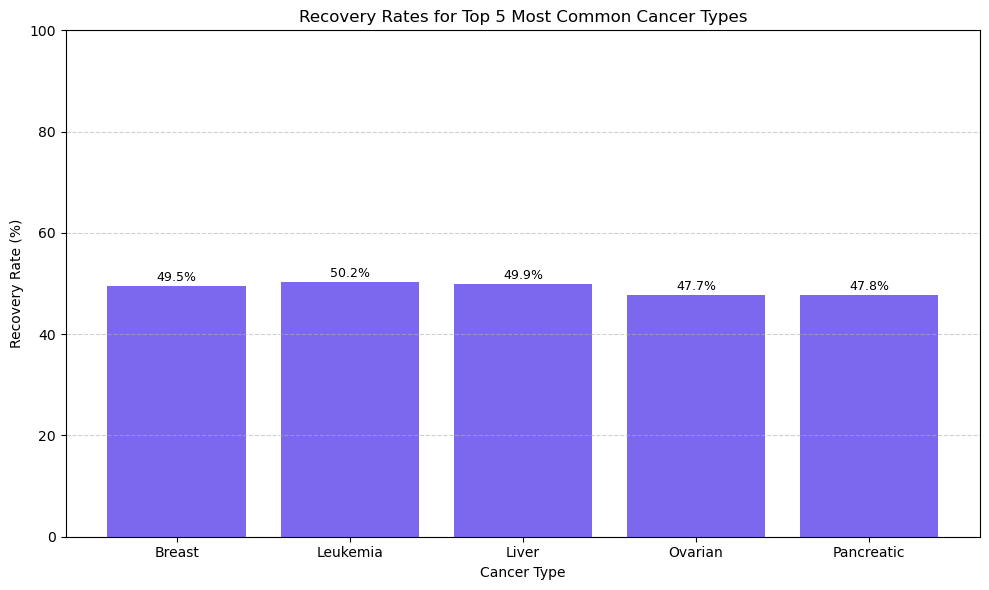

In [31]:
import pandas as pd
import matplotlib.pyplot as plt

# Step 1: Top 5 most common cancer types
top5_cancer_types = df['cancer_type'].value_counts().nlargest(5).index

# Step 2: Filter dataframe for those top 5 types
top5_df = df[df['cancer_type'].isin(top5_cancer_types)]

# Step 3: Calculate recovery rate for each of the top 5
recovery_stats = top5_df.groupby('cancer_type')['recovered'].agg(['sum', 'count']).reset_index()
recovery_stats['recovery_rate'] = (recovery_stats['sum'] / recovery_stats['count']) * 100

# Step 4: Plotting
plt.figure(figsize=(10, 6))
bars = plt.bar(recovery_stats['cancer_type'], recovery_stats['recovery_rate'], color='mediumslateblue')

# Add data labels
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 1,
             f'{height:.1f}%', ha='center', fontsize=9)

plt.title('Recovery Rates for Top 5 Most Common Cancer Types')
plt.xlabel('Cancer Type')
plt.ylabel('Recovery Rate (%)')
plt.ylim(0, 100)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()